# capitulo3_pseudotime — Pseudotime Trajectory Analysis (Part 3)
## Requires: pbmc_harmony_curated.h5ad from capitulo1_single_cell.R

Run each section **in order**. Read the comments in each cell before changing parameters.

---
## SECTION 24 — Setup
Sets paths and loads libraries. Only change `PIPELINE_DIR` and `DATA_DIR` if your folder structure is different.

In [90]:
import os

# ── Paths (must match capitulo1_single_cell.R) ────────────────────────────────
PIPELINE_DIR = os.path.expanduser("~/projects2/eleo/ScRNA/metodologia/ScRNASeq-Docker/")
DATA_DIR     = os.path.expanduser("~/projects2/eleo/ScRNA/")
base_dir     = os.path.join(DATA_DIR, "metodologia/resultados")

# Load libraries and functions (equivalent to source() in R)
exec(open(os.path.join(PIPELINE_DIR, "load_libraries_python.py")).read(), globals())
exec(open(os.path.join(PIPELINE_DIR, "ScRNA_Pseudotime_Functions.py")).read(), globals())

dir_pseudotime = os.path.join(base_dir, "09_pseudotime")
os.makedirs(dir_pseudotime, exist_ok=True)

print("SECTION 24 COMPLETE: Setup done")

SECTION 24 COMPLETE: Setup done


---
## SECTION 25 — Load Data
Loads the AnnData object (`.h5ad`) exported from Seurat by capitulo1.

**What this section does:**
1. Reads the `.h5ad` file with all cells, genes, and metadata from capitulo1
2. Converts the UMAP and PCA coordinates from R format to scanpy format
3. Prints the available cell type names — **you will need these for Section 26**
4. Plots a UMAP as a visual check that the object loaded correctly

**Parameter to set:**
- `ANNOTATION_COL`: the column with your final cell type labels
  - Run `print(adata.obs.columns.tolist())` to see all available columns
  - Common options: `celltype_curated`, `celltype_reference`, `seurat_clusters`
- `N_JOBS`: CPU cores for parallel steps (4–8 on a laptop, up to 32 on server)

Cell types available in celltype_curated :
['Bundle Sheath', 'Cell Cycle: G1-S', 'Cell Cycle: G2-M', 'Guard Cell', 'Hydathode', 'Mesophyll', 'Myrosin Idioblast', 'Pavement Cell', 'Stomatal Line', 'Vascular Cell']


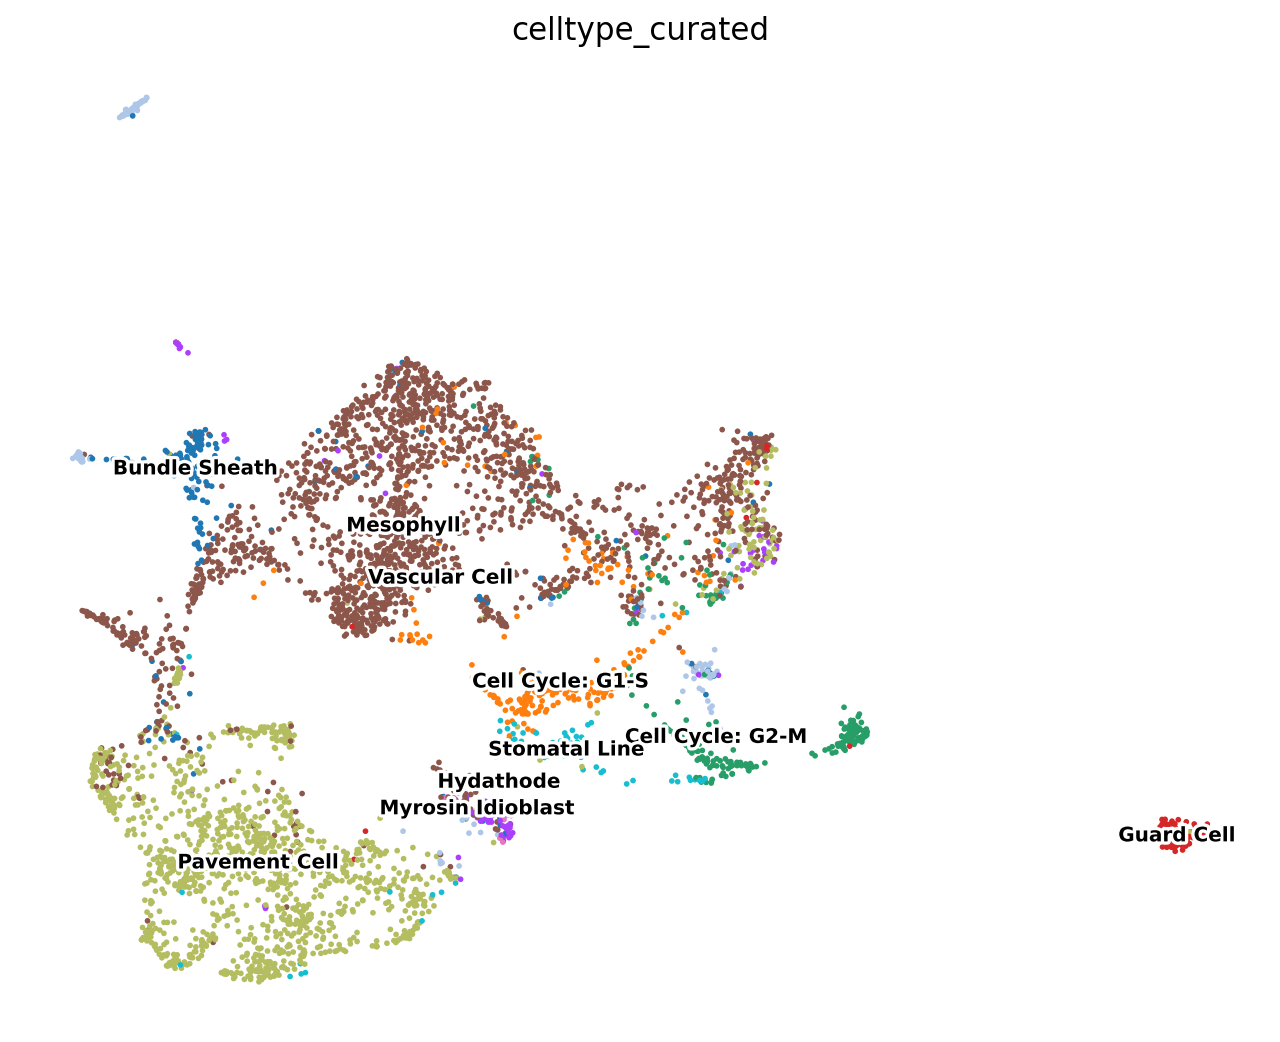


SECTION 25 COMPLETE: Object loaded


In [91]:
# ┌─ PARAMETERS ───────────────────────────────────────────────────────────────
#   ANNOTATION_COL : column in adata.obs with your final cell type labels
#                    Run: print(adata.obs.columns.tolist()) to see all options
#   N_JOBS         : CPU cores (4–8 laptop, up to 32 server)
# └────────────────────────────────────────────────────────────────────────────
ANNOTATION_COL = "celltype_curated"  # change to your cell type column
N_JOBS         = 4                   # adjust to your machine

dir_objects = os.path.join(base_dir, "objects")

# Load the object from capitulo1
adata = sc.read_h5ad(os.path.join(dir_objects, "pbmc_harmony_curated.h5ad"))

# Convert R-format keys to scanpy format
adata.obsm["X_umap"] = adata.obsm["UMAP"].values
adata.obsm["X_pca"]  = adata.obsm["PCA"].values

sc.settings.figdir = dir_pseudotime
# figsize matches R save_pdf default (w=10, h=8); dpi_save=300 for export
sc.set_figure_params(figsize=(10, 8), dpi=80, dpi_save=300)

# Read these names — use them to set TRAJECTORY_CLUSTERS in Section 26
print("Cell types available in", ANNOTATION_COL, ":")
print(sorted(adata.obs[ANNOTATION_COL].unique().tolist()))

# Matches R: label=TRUE, repel=TRUE, raster=FALSE
# In Jupyter we build the figure explicitly so it is displayed once inline and saved.
fig = sc.pl.umap(
    adata,
    color              = ANNOTATION_COL,
    legend_loc         = "on data",   # label=TRUE in R
    legend_fontsize    = 9,
    legend_fontoutline = 3,           # repel=TRUE equivalent
    frameon            = False,
    show               = False,
    return_fig         = True,
)

fig.savefig(
    os.path.join(dir_pseudotime, "umap_overview.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nSECTION 25 COMPLETE: Object loaded")


---
## SECTION 26 — Cell Type Selection
Shows the available cell types and plots a UMAP of your selected subset.

**What to do:**
1. Run the cell — reads the available cell types and their counts
2. Edit `TRAJECTORY_CLUSTERS` with the names you want to include
3. Re-run — plots the subset UMAP so you can verify before continuing

Annotation column: 'celltype_curated'

   1.  Bundle Sheath                    210 cells
   2.  Cell Cycle: G1-S                 245 cells
   3.  Cell Cycle: G2-M                 240 cells
   4.  Guard Cell                       109 cells
   5.  Hydathode                        111 cells
   6.  Mesophyll                       2128 cells
   7.  Myrosin Idioblast                  6 cells
   8.  Pavement Cell                   1283 cells
   9.  Stomatal Line                     75 cells
  10.  Vascular Cell                    151 cells

Selected 1467 cells from: ['Pavement Cell', 'Guard Cell', 'Stomatal Line']


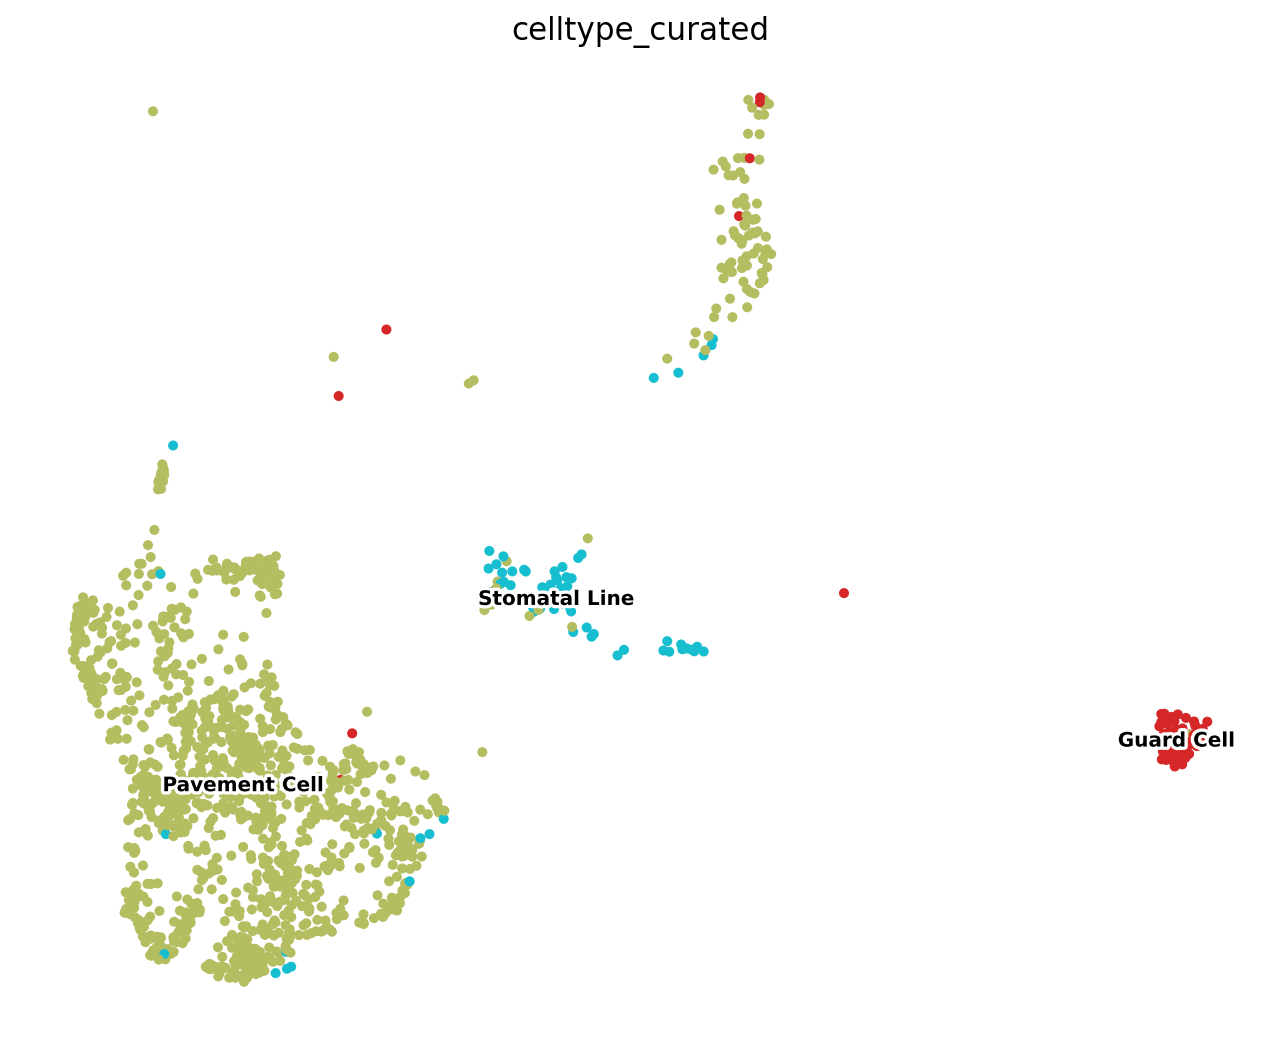


SECTION 26 COMPLETE: if the subset UMAP looks correct, proceed to Section 27


In [92]:
# ── Available cell types in the selected annotation column ───────────────────
print(f"Annotation column: '{ANNOTATION_COL}'")
print()
counts = adata.obs[ANNOTATION_COL].value_counts()
for i, ct in enumerate(sorted(adata.obs[ANNOTATION_COL].unique().tolist()), 1):
    print(f"  {i:2d}.  {ct:<30s} {counts[ct]:>5d} cells")
print()

# ┌─ PARAMETERS ────────────────────────────────────────────────────────────────
#   TRAJECTORY_CLUSTERS : cell types to include — copy names exactly from above
# └────────────────────────────────────────────────────────────────────────────
TRAJECTORY_CLUSTERS = ["Pavement Cell", "Guard Cell", "Stomatal Line"]  # edit

# Subset and plot to verify
adata_sub = adata[adata.obs[ANNOTATION_COL].isin(TRAJECTORY_CLUSTERS)].copy()
print(f"Selected {len(adata_sub)} cells from: {TRAJECTORY_CLUSTERS}")

fig = sc.pl.umap(
    adata_sub,
    color              = ANNOTATION_COL,
    legend_loc         = "on data",
    legend_fontsize    = 9,
    legend_fontoutline = 3,
    frameon            = False,
    show               = False,
    return_fig         = True,
)
fig.savefig(
    os.path.join(dir_pseudotime, "umap_selection.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)
print("\nSECTION 26 COMPLETE: if the subset UMAP looks correct, proceed to Section 27")


---
## SECTION 27 — Trajectory Inference
Builds a tree-shaped trajectory through the cell types selected in Section 26.

**Parameters to set:**
- `ROOT_CLUSTER`: the progenitor — where pseudotime = 0 (must be one of your Section 26 types)
- `NODES`, `SIGMA`, `PPT_LAMBDA`, `N_EIGS`: tree shape (defaults work for most cases)


Running: run_1_simple
Results folder: /home/mvergara/projects2/eleo/ScRNA/metodologia/resultados/09_pseudotime/trajectory/run_1_simple
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (ad

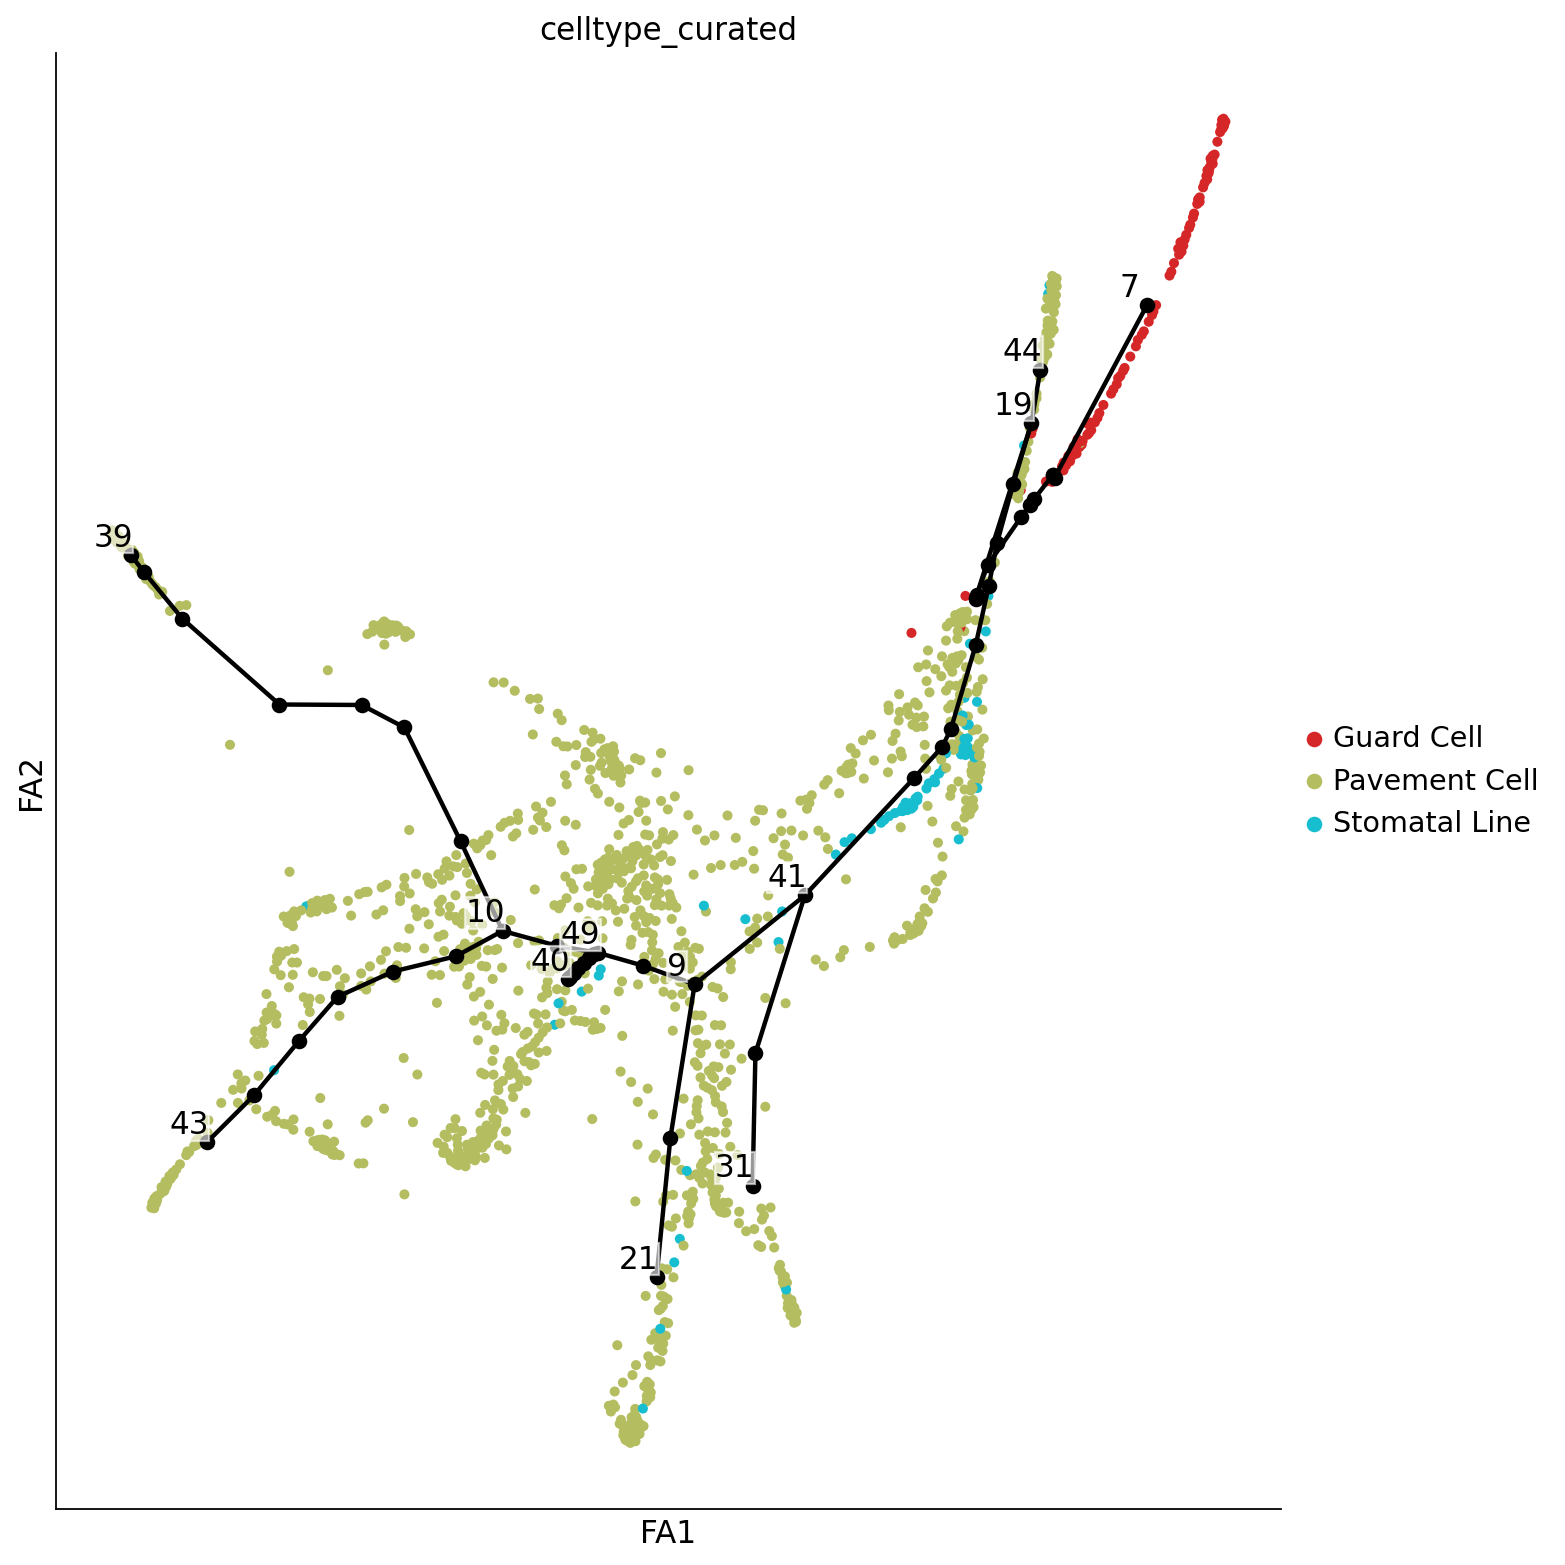

✓ Trajectory graphs saved to /home/mvergara/projects2/eleo/ScRNA/metodologia/resultados/09_pseudotime/trajectory/run_1_simple

STEP 27 COMPLETE
Selected run: run_1_simple
Selected folder: /home/mvergara/projects2/eleo/ScRNA/metodologia/resultados/09_pseudotime/trajectory/run_1_simple


In [93]:
# STEP 27 — Build trajectory
#
# ROOT_CLUSTER is chosen from biology: literature, markers, or prior knowledge.
# TRAJECTORY_RUNS can have one or many options. If it has several, all are run.

ROOT_CLUSTER = "Stomatal Line"

TRAJECTORY_RUNS = [
    {"name": "run_1_simple", "nodes": 50, "sigma": 0.2, "lambda": 60, "eigs": 20},

    # Optional comparison runs. Delete or edit these if you do not need them.
    # {"name": "run_2_smoother", "nodes": 100, "sigma": 0.2, "lambda": 100, "eigs": 20},
    # {"name": "run_3_more_detail", "nodes": 100, "sigma": 0.1, "lambda": 60, "eigs": 20},
]

# If you run several options, write here the one you want to continue with.
# If this is None, the notebook continues with the last run in TRAJECTORY_RUNS.
# Example: SELECTED_RUN = "run_2_smoother"
SELECTED_RUN = None

adata_traj, selected_trajectory_dir, trajectory_runs = run_trajectory_runs(
    adata           = adata,
    clusters        = TRAJECTORY_CLUSTERS,
    root_cluster    = ROOT_CLUSTER,
    annotation_col  = ANNOTATION_COL,
    output_base_dir = dir_pseudotime,
    runs            = TRAJECTORY_RUNS,
    selected_run    = SELECTED_RUN,
)


---
## SECTION 28 — Dendrogram and Milestones
Identifies branch endpoints (milestones). **Read the milestone names printed below before running Section 29.**

In [ ]:
adata_traj = build_dendrogram(adata_traj)

# This table tells where each selected cell type falls across the milestones.
summary_milestones, milestone_counts, milestone_percents = summarize_milestones_by_celltype(
    adata          = adata_traj,
    annotation_col = ANNOTATION_COL,
    output_dir     = selected_trajectory_dir,
    root_cluster   = ROOT_CLUSTER,
)

# Rename milestones. The root cell type is forced to appear in the dendrogram.
adata_traj = rename_milestones_by_celltype(
    adata_traj,
    ANNOTATION_COL,
    priority_celltypes=[ROOT_CLUSTER],
)

print("\nAvailable milestones for downstream analysis:")
print(sorted(adata_traj.obs["milestones"].unique().tolist()))

sc.settings.figdir = selected_trajectory_dir
sc.set_figure_params(dpi_save=600)

# 1) Dendrogram colored by milestones
scf.pl.dendrogram(
    adata_traj,
    color      = "milestones",
    legend_loc = "on data",
    save       = "_milestones.pdf",
)

# 2) Same UMAP from Step 27, colored by milestones
fig = sc.pl.umap(
    adata_traj,
    color              = "milestones",
    legend_loc         = "on data",
    legend_fontsize    = 9,
    legend_fontoutline = 3,
    frameon            = False,
    show               = False,
    return_fig         = True,
)
fig.savefig(
    os.path.join(selected_trajectory_dir, "umap_milestones.png"),
    dpi=600,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print("\nSTEP 28 COMPLETE")


---
## SECTION 29 — Milestone Analysis
For each branch endpoint: tests which genes change significantly along that path and fits smooth expression curves.

**Parameters to set:**
- `MILESTONES_TO_ANALYZE`: use the names printed in Section 28
- `A_CUT`: lower = more genes (noisier), higher = fewer genes (more selective)

In [ ]:
# ┌─ PARAMETERS ───────────────────────────────────────────────────────────────
#   MILESTONES_TO_ANALYZE : adjust after reading Section 28 output
#   A_CUT                 : association threshold (0–1); start at 0.3
#   P_VAL_CUT             : p-value significance threshold
# └────────────────────────────────────────────────────────────────────────────
MILESTONES_TO_ANALYZE = ["Guard Cell", "Pavement Cell"]  # adjust after Section 28
A_CUT     = 0.3
P_VAL_CUT = 0.001

fitted_objects = {}

for milestone in MILESTONES_TO_ANALYZE:
    fitted_objects[milestone] = run_milestone_analysis(
        adata         = adata_traj,
        milestone     = milestone,
        root_milestone= ROOT_CLUSTER,
        output_dir    = os.path.join(selected_trajectory_dir, "milestones"),
        n_jobs        = N_JOBS,
        a_cut         = A_CUT,
        p_val_cut     = P_VAL_CUT,
        name_file     = SELECTED_RUN,
    )

print("\nSECTION 30 COMPLETE")

---
## SECTION 30 — Gene Expression Trends
Heatmap of the most dynamically expressed genes per branch + ranked CSV table.

**Parameters to set:**
- `HIGHLIGHT_GENES`: known marker genes to highlight (leave `[]` if none)

In [ ]:
# ┌─ PARAMETERS ───────────────────────────────────────────────────────────────
#   HIGHLIGHT_GENES : known markers to highlight in the trends heatmap
#                     Use gene IDs for your organism:
#                       Arabidopsis: TAIR IDs e.g. "AT3G24140"
#                       Human/mouse: gene symbols e.g. "MYC", "SOX2"
#                     Leave as [] if you have no prior markers
# └────────────────────────────────────────────────────────────────────────────
HIGHLIGHT_GENES = ["AT5G53210"]  # e.g. ["AT5G53210", "AT3G06120"]

for milestone, adata_fitted in fitted_objects.items():
    plot_gene_trends(
        adata_fitted    = adata_fitted,
        milestone_name  = milestone,
        output_dir      = os.path.join(selected_trajectory_dir, "trends"),
        highlight_genes = HIGHLIGHT_GENES,
    )
    genes_by_pseudotime_peak(
        adata          = adata_fitted,
        milestone_name = milestone,
        output_dir     = os.path.join(selected_trajectory_dir, "tables"),
    )

print("\nSECTION 30 COMPLETE")

---
## SECTION 31 — Module Scores *(optional)*
Projects user-defined gene lists onto the trajectory as per-cell scores.
**Skip this section if you do not have custom gene lists.**

**Parameters to set:**
- `MODULE_GENE_FILES`: dict of `{label: path_to_file}` — leave `{}` to skip
- `MODULE_ID_COL`: column name with gene IDs in each file

In [ ]:
# ┌─ PARAMETERS ───────────────────────────────────────────────────────────────
#   MODULE_GENE_FILES : add your gene list files here, or leave as {} to skip
#                       e.g. {"my_module": "/path/to/genes.txt"}
#   MODULE_ID_COL     : column with gene IDs in each file
#                       Arabidopsis: usually "ID" or "TAIR"
#                       Human/mouse: usually "gene_id" or "symbol"
# └────────────────────────────────────────────────────────────────────────────
MODULE_GENE_FILES = {}    # e.g. {"cluster1": "/path/to/cluster1_genes.txt"}
MODULE_ID_COL     = "ID"

module_score_dir = os.path.join(selected_trajectory_dir, "module_scores")
os.makedirs(module_score_dir, exist_ok=True)
sc.settings.figdir = module_score_dir

if MODULE_GENE_FILES:
    for label, fpath in MODULE_GENE_FILES.items():
        df        = pd.read_csv(fpath, sep="\t")
        gene_list = df[MODULE_ID_COL].dropna().unique().tolist()
        compute_module_score(adata_traj, gene_list, label)

    sc.pl.draw_graph(
        adata_traj,
        color  = [f"{label}_module_score" for label in MODULE_GENE_FILES],
        cmap   = "viridis",
        show   = False,
        save   = "_module_scores.png",
    )
    print("Module score plots saved")
else:
    print("Section 31 skipped — no MODULE_GENE_FILES defined")

print("\nSECTION 31 COMPLETE")